# Smoke Detection IoT

This notebook analyzes the smoke detection IoT dataset before model training.

Only the needed columns are kept:

- `Temperature[C]`
- `Humidity[%]`
- `TVOC[ppb]`
- `eCO2[ppm]`
- `Fire Alarm`

These columns are renamed to simple ML-friendly names after loading the raw CSV.


#### 1. Imports


In [8]:
# Import the libraries needed for data analysis, visualization, preprocessing, and modeling.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')


#### 2. Load Data


In [9]:
# Load the original raw smoke detection dataset.
raw_smoke_data = pd.read_csv('smoke_detection_iot.csv')

print('Raw smoke dataset shape:', raw_smoke_data.shape)
display(raw_smoke_data.head())


Raw smoke dataset shape: (62630, 16)


,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


#### 3. Keep Only Needed Columns and Rename Them

The raw dataset contains extra sensor columns that I do not need for this ML version. I will keep only the selected features and target label, then rename them for easier use.


In [10]:
# Keep only the columns needed for this project and rename them clearly.
columns_to_keep = ['Temperature[C]', 'Humidity[%]', 'TVOC[ppb]', 'eCO2[ppm]', 'Fire Alarm']

smoke_data_clean = raw_smoke_data[columns_to_keep].copy()

smoke_data_clean = smoke_data_clean.rename(columns={
    'Temperature[C]': 'temperature',
    'Humidity[%]': 'humidity',
    'TVOC[ppb]': 'tvoc_ppb',
    'eCO2[ppm]': 'eco2_ppm',
    'Fire Alarm': 'fire_alarm'
})

print('Smoke clean dataset shape after keeping needed columns:', smoke_data_clean.shape)

print('Easy-to-understand column names:')
print(smoke_data_clean.columns.tolist())

display(smoke_data_clean.head())


Smoke clean dataset shape after keeping needed columns: (62630, 5)
Easy-to-understand column names:
['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm', 'fire_alarm']


,temperature,humidity,tvoc_ppb,eco2_ppm,fire_alarm
0,20.000,57.36,0,400,0
1,20.015,56.67,0,400,0
2,20.029,55.96,0,400,0
3,20.044,55.28,0,400,0
4,20.059,54.69,0,400,0


#### 4. Add a Human-Readable Alarm Status Column

`fire_alarm` stays as the numeric target column for machine learning. `alarm_status` is only a readable label that helps with analysis, charts, and explanations.


In [11]:
# Add a readable label column for charts and explanations.
smoke_data_clean['alarm_status'] = smoke_data_clean['fire_alarm'].map({
    0: 'No Smoke',
    1: 'Smoke'
})

print('Columns after adding readable label:')
print(smoke_data_clean.columns.tolist())

display(smoke_data_clean.head(10))


Columns after adding readable label:
['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm', 'fire_alarm', 'alarm_status']


,temperature,humidity,tvoc_ppb,eco2_ppm,fire_alarm,alarm_status
0,20.000,57.36,0,400,0,No Smoke
1,20.015,56.67,0,400,0,No Smoke
2,20.029,55.96,0,400,0,No Smoke
3,20.044,55.28,0,400,0,No Smoke
4,20.059,54.69,0,400,0,No Smoke
5,20.073,54.12,0,400,0,No Smoke
6,20.088,53.61,0,400,0,No Smoke
7,20.103,53.20,0,400,0,No Smoke
8,20.117,52.81,0,400,0,No Smoke
9,20.132,52.46,0,400,0,No Smoke


#### 5. Preprocessing: Export Clean Data to Formatted Excel

This step saves the cleaned dataframe as a new `.xlsx` file for viewing and sharing.

The original raw CSV is still kept unchanged. The model does not need to read this Excel file; the notebook continues using `smoke_data_clean` in memory.


In [ ]:
# Export the cleaned dataframe to a formatted Excel file for viewing and sharing.

excel_file_name = 'smoke_detection_clean_formatted.xlsx'

# Put columns in a clear order for Excel viewing.
excel_data = smoke_data_clean[[
    'temperature',
    'humidity',
    'tvoc_ppb',
    'eco2_ppm',
    'alarm_status',
    'fire_alarm'
]].copy()

with pd.ExcelWriter(excel_file_name, engine='openpyxl') as writer:
    excel_data.to_excel(writer, sheet_name='Clean Smoke Data', index=False)

    workbook = writer.book
    worksheet = writer.sheets['Clean Smoke Data']

    header_fill = PatternFill(start_color='1F4E78', end_color='1F4E78', fill_type='solid')
    header_font = Font(color='FFFFFF', bold=True)
    thin_gray_border = Border(
        left=Side(style='thin', color='D9E2F3'),
        right=Side(style='thin', color='D9E2F3'),
        top=Side(style='thin', color='D9E2F3'),
        bottom=Side(style='thin', color='D9E2F3')
    )

    # Style all cells and make the header stand out.
    for row in worksheet.iter_rows():
        for cell in row:
            cell.border = thin_gray_border
            cell.alignment = Alignment(vertical='center')
            if cell.row == 1:
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = Alignment(horizontal='center', vertical='center')

    # Set readable column widths.
    column_widths = {
        'A': 14,  # temperature
        'B': 12,  # humidity
        'C': 12,  # tvoc_ppb
        'D': 12,  # eco2_ppm
        'E': 16,  # alarm_status
        'F': 12   # fire_alarm
    }

    for column_letter, width in column_widths.items():
        worksheet.column_dimensions[column_letter].width = width

    # Freeze the header row and add filters.
    worksheet.freeze_panes = 'A2'
    worksheet.auto_filter.ref = worksheet.dimensions

    # Optional number formatting.
    for row in range(2, worksheet.max_row + 1):
        worksheet[f'A{row}'].number_format = '0.00'
        worksheet[f'B{row}'].number_format = '0.00'
        worksheet[f'C{row}'].number_format = '0'
        worksheet[f'D{row}'].number_format = '0'
        worksheet[f'F{row}'].number_format = '0'

print(f'Formatted Excel file saved as: {excel_file_name}')


#### 6. Initial Overview


In [12]:
# Show data types, non-null counts, and summary statistics for the cleaned data.
print('Data types and non-null values:')
smoke_data_clean.info()

smoke_data_clean.describe(include='all').round(2).T



Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temperature   62630 non-null  float64
 1   humidity      62630 non-null  float64
 2   tvoc_ppb      62630 non-null  int64  
 3   eco2_ppm      62630 non-null  int64  
 4   fire_alarm    62630 non-null  int64  
 5   alarm_status  62630 non-null  object 
dtypes: float64(2), int64(3), object(1)
memory usage: 2.9+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
temperature,62630.0,NaN,NaN,NaN,15.97,14.36,-22.01,10.99,20.13,25.41,59.93
humidity,62630.0,NaN,NaN,NaN,48.54,8.87,10.74,47.53,50.15,53.24,75.2
tvoc_ppb,62630.0,NaN,NaN,NaN,1942.06,7811.59,0.0,130.0,981.0,1189.0,60000.0
eco2_ppm,62630.0,NaN,NaN,NaN,670.02,1905.89,400.0,400.0,400.0,438.0,60000.0
fire_alarm,62630.0,NaN,NaN,NaN,0.71,0.45,0.0,0.0,1.0,1.0,1.0
alarm_status,62630,2,Smoke,44757,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 7. Analysis: Duplicate and Missing Values


In [13]:
# Check whether the cleaned data has duplicate rows or missing values.
duplicate_rows_count = smoke_data_clean.duplicated().sum()
duplicate_rows_percent = duplicate_rows_count / len(smoke_data_clean) * 100

print(f'Duplicate rows after keeping selected columns: {duplicate_rows_count} ({duplicate_rows_percent:.2f}%)')

missing_values_count = smoke_data_clean.isna().sum()
missing_values_percent = smoke_data_clean.isna().mean() * 100
missing_values_summary = pd.DataFrame({
    'missing_count': missing_values_count,
    'missing_values_percent': missing_values_percent
}).sort_values('missing_values_percent', ascending=False)

display(missing_values_summary)


Duplicate rows after keeping selected columns: 41 (0.07%)


,missing_count,missing_values_percent
temperature,0,0.0
humidity,0,0.0
tvoc_ppb,0,0.0
eco2_ppm,0,0.0
fire_alarm,0,0.0
alarm_status,0,0.0


#### 8. Target Check


,count,percent
fire_alarm,,
Normal,17873,28.54%
Fire,44757,71.46%


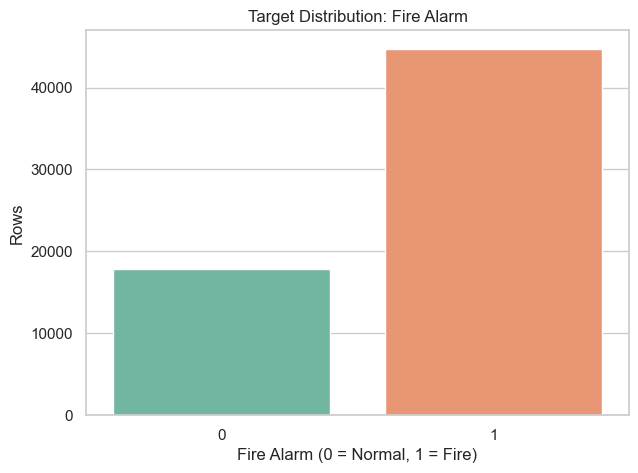

In [14]:
# Check how many rows belong to each target class.
fire_alarm_counts = smoke_data_clean['fire_alarm'].value_counts().sort_index()
fire_alarm_percent = smoke_data_clean['fire_alarm'].value_counts(normalize=True).sort_index() * 100

fire_alarm_summary = pd.DataFrame({
    'count': fire_alarm_counts,
    'percent': fire_alarm_percent.map(lambda value: f'{value:.2f}%')
})
fire_alarm_summary.index = fire_alarm_summary.index.map({0: 'Normal', 1: 'Fire'})

display(fire_alarm_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=smoke_data_clean, x='fire_alarm', hue='fire_alarm', palette='Set2', legend=False)
plt.title('Target Distribution: Fire Alarm')
plt.xlabel('Fire Alarm (0 = Normal, 1 = Fire)')
plt.ylabel('Rows')
plt.show()


#### 9. Feature Summary


In [15]:
# Summarize the numeric sensor feature columns.
sensor_feature_columns = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']

smoke_data_clean[sensor_feature_columns].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
temperature,62630.0,15.97,14.36,-22.01,10.99,20.13,25.41,59.93
humidity,62630.0,48.54,8.87,10.74,47.53,50.15,53.24,75.20
tvoc_ppb,62630.0,1942.06,7811.59,0.00,130.00,981.00,1189.00,60000.00
eco2_ppm,62630.0,670.02,1905.89,400.00,400.00,400.00,438.00,60000.00


#### 10. Feature Distributions


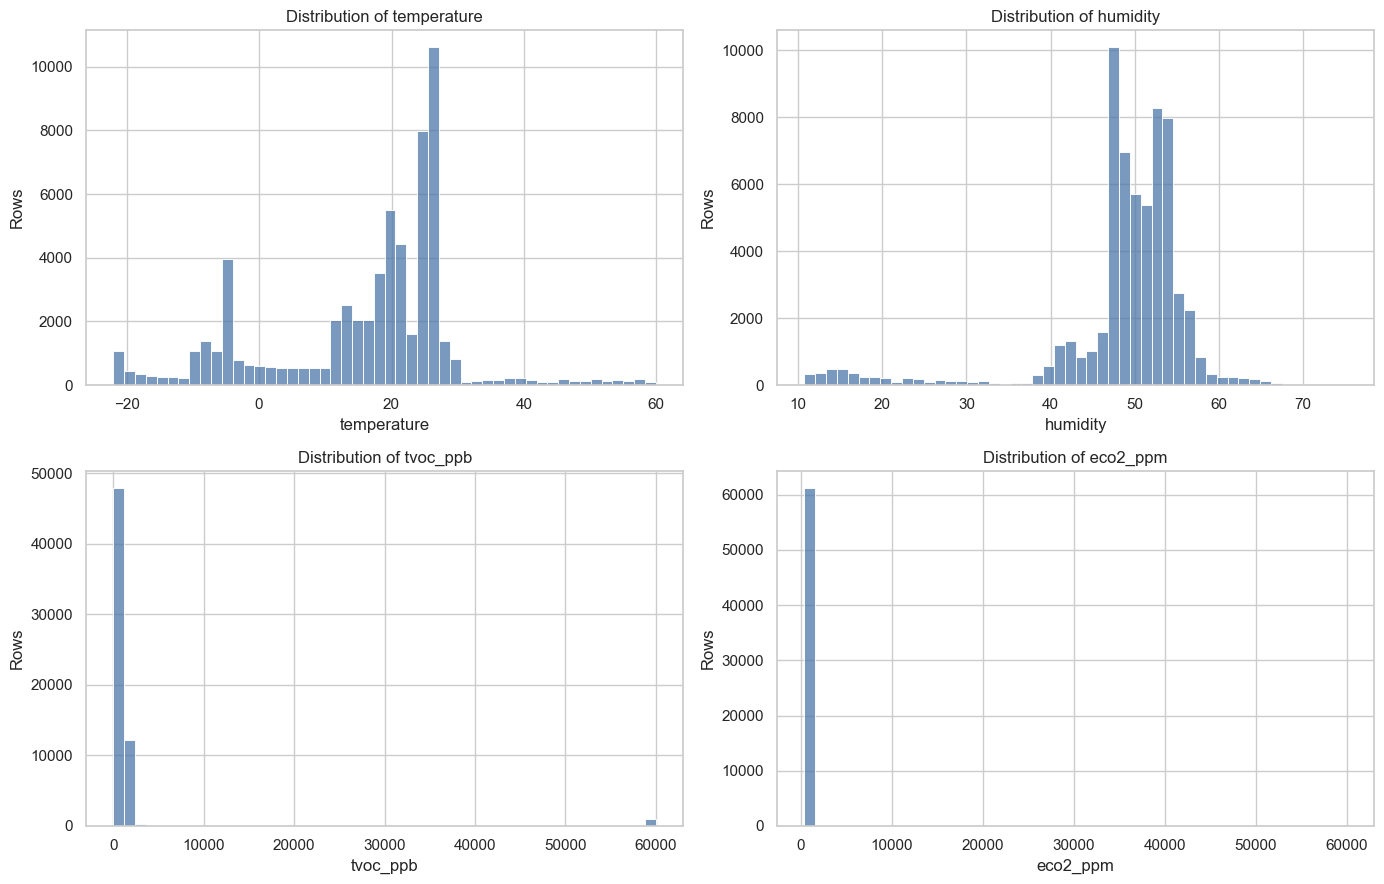

In [16]:
# Plot distributions for each sensor feature.
sensor_feature_columns = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, column in zip(axes, sensor_feature_columns):
    sns.histplot(data=smoke_data_clean, x=column, bins=50, ax=ax, color='#4C78A8')
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Rows')

plt.tight_layout()
plt.show()


#### 11. Class-wise Feature Comparison


In [17]:
# Compare sensor feature values between no-smoke and smoke rows.
feature_summary_by_fire_alarm = smoke_data_clean.groupby('fire_alarm')[sensor_feature_columns].agg(['min', 'median', 'mean', 'max']).T
feature_summary_by_fire_alarm.columns = ['Normal', 'Fire']
display(feature_summary_by_fire_alarm)


Normal          Fire
temperature min       -22.010000    -22.010000
            median     20.540000     20.020000
            mean       19.694803     14.483152
            max        59.930000     41.410000
humidity    min        10.740000     13.360000
            median     46.140000     51.400000
            mean       42.930077     50.779534
            max        75.200000     70.280000
tvoc_ppb    min         0.000000      0.000000
            median     86.000000   1103.000000
            mean     4596.587255    882.013071
            max     60000.000000  18062.000000
eco2_ppm    min       400.000000    400.000000
            median    400.000000    404.000000
            mean      962.587255    553.189356
            max     39185.000000  60000.000000

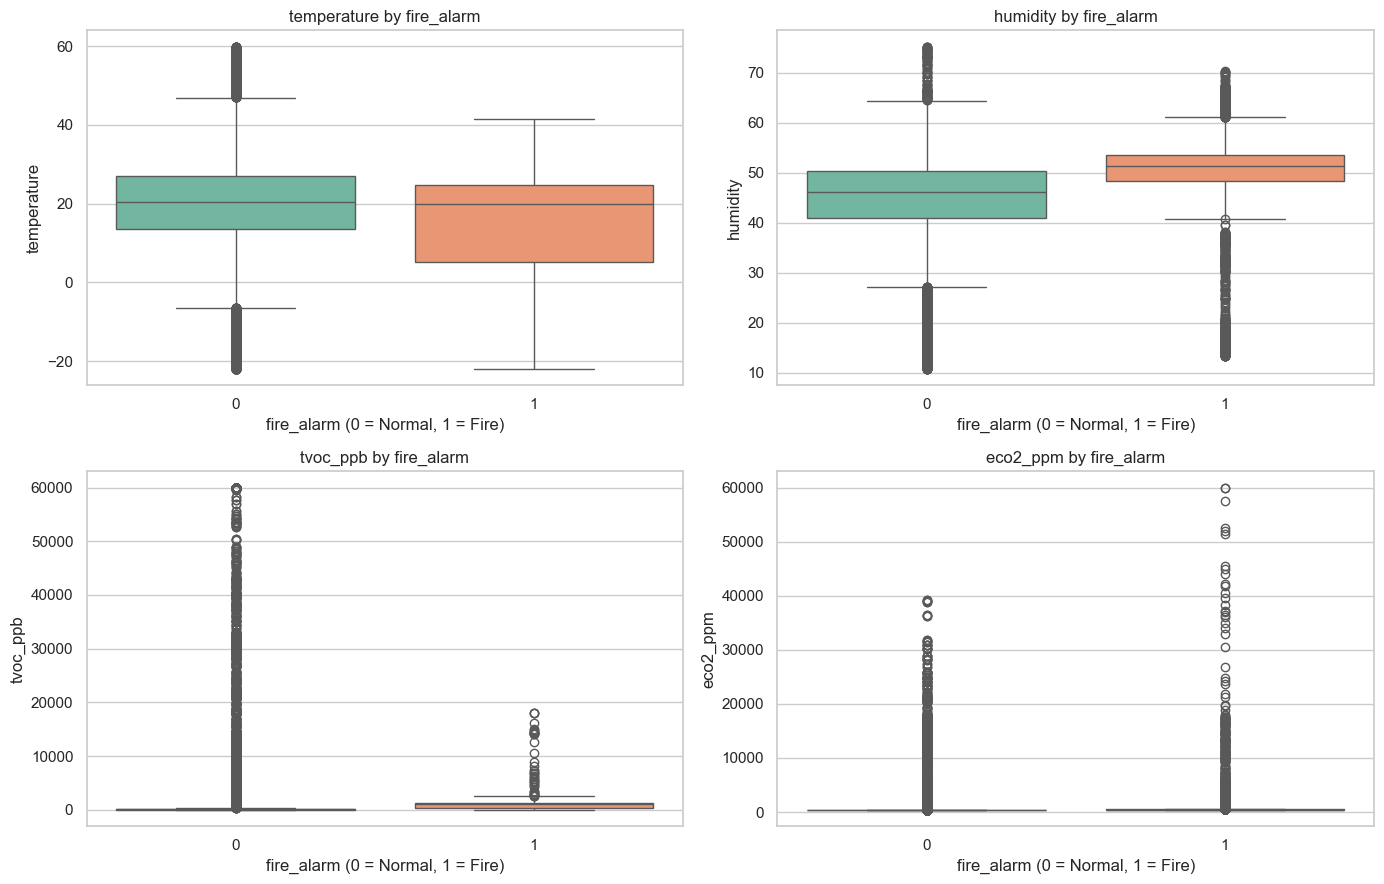

In [18]:
# Visualize class-wise feature differences with boxplots.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, column in zip(axes, sensor_feature_columns):
    sns.boxplot(data=smoke_data_clean, x='fire_alarm', y=column, hue='fire_alarm', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{column} by fire_alarm')
    ax.set_xlabel('fire_alarm (0 = Normal, 1 = Fire)')

plt.tight_layout()
plt.show()


#### 12. Outlier Analysis Using IQR


In [19]:
# Detect possible outliers in each sensor feature using the IQR rule.
outlier_analysis_rows = []

for column in sensor_feature_columns:
    q1 = smoke_data_clean[column].quantile(0.25)
    q3 = smoke_data_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((smoke_data_clean[column] < lower_bound) | (smoke_data_clean[column] > upper_bound)).sum()
    outlier_analysis_rows.append({
        'feature': column,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outlier_count,
        'outlier_percent': outlier_count / len(smoke_data_clean) * 100
    })

iqr_outlier_summary = pd.DataFrame(outlier_analysis_rows)
display(iqr_outlier_summary)


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
0,temperature,10.99425,25.4095,14.41525,-10.628625,47.032375,3908,6.239821
1,humidity,47.53000,53.2400,5.71000,38.965000,61.805000,5083,8.115919
2,tvoc_ppb,130.00000,1189.0000,1059.00000,-1458.500000,2777.500000,2463,3.932620
3,eco2_ppm,400.00000,438.0000,38.00000,343.000000,495.000000,12076,19.281494


#### 13. Correlation Analysis


,temperature,humidity,tvoc_ppb,eco2_ppm,fire_alarm
temperature,1.000000,-0.243986,0.082442,0.079265,-0.163902
humidity,-0.243986,1.000000,-0.488878,-0.369095,0.399846
tvoc_ppb,0.082442,-0.488878,1.000000,0.606118,-0.214743
eco2_ppm,0.079265,-0.369095,0.606118,1.000000,-0.097006
fire_alarm,-0.163902,0.399846,-0.214743,-0.097006,1.000000


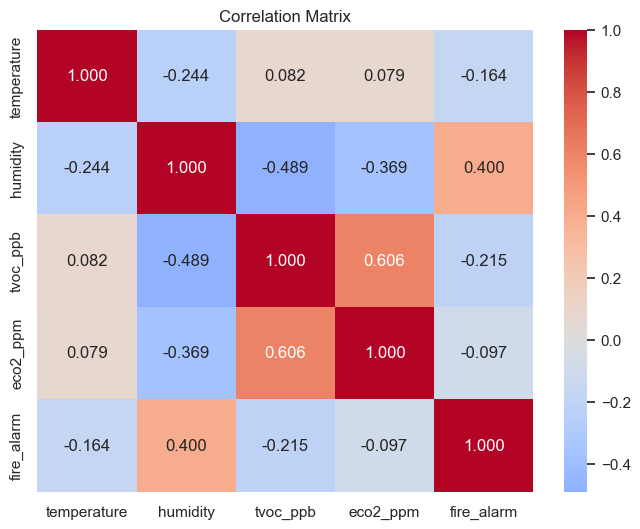

In [20]:
# Check linear correlations between sensor features and the target column.
correlation_columns_to_check = sensor_feature_columns + ['fire_alarm']
sensor_correlation_matrix = smoke_data_clean[correlation_columns_to_check].corr(numeric_only=True)

display(sensor_correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(sensor_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix')
plt.show()


#### 14. Analysis Takeaways

So far we have done the first cleaning step and several analysis checks:

- Kept only the needed columns.
- Renamed columns to easy names.
- Checked missing values and duplicate rows.
- Checked the target distribution.
- Compared sensor values between normal and fire rows.
- Checked outliers with IQR.
- Checked correlation between features and the target.

Before modeling, we should prepare the final feature matrix and target variable, then split the data into training and testing sets.


#### 15. Preprocessing: Prepare Features and Target

Here we separate the input sensor features from the target label.

- `features_col` contains the sensor readings used by the model.
- `target_col` contains the answer the model should predict.


In [21]:
# Separate input features from the target column.
features_col = smoke_data_clean[['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']]
target_col = smoke_data_clean['fire_alarm']

print('Feature column shape:', features_col.shape)
print('Target column shape:', target_col.shape)

display(features_col.head())
display(target_col.head())


Feature column shape: (62630, 4)
Target column shape: (62630,)


,temperature,humidity,tvoc_ppb,eco2_ppm
0,20.000,57.36,0,400
1,20.015,56.67,0,400
2,20.029,55.96,0,400
3,20.044,55.28,0,400
4,20.059,54.69,0,400


0    0
1    0
2    0
3    0
4    0
Name: fire_alarm, dtype: int64

#### 16. Train / Validation / Test Split

We split the data into three parts:

- Training set: used to train the models
- Validation set: used to compare models and choose the best one
- Test set: used only at the end for the final evaluation

This is better than choosing a model directly from the test set.


In [22]:
# Split the data into train, validation, and test sets.

X_train_val, X_test, y_train_val, y_test = train_test_split(
    features_col,
    target_col,
    test_size=0.2,
    random_state=42,
    stratify=target_col
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val
)

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)
print('y_test:', y_test.shape)

print('\nTraining target distribution:')
display((y_train.value_counts(normalize=True).sort_index() * 100).map(lambda value: f'{value:.2f}%'))

print('\nValidation target distribution:')
display((y_val.value_counts(normalize=True).sort_index() * 100).map(lambda value: f'{value:.2f}%'))

print('\nTest target distribution:')
display((y_test.value_counts(normalize=True).sort_index() * 100).map(lambda value: f'{value:.2f}%'))


X_train: (40083, 4)
X_val: (10021, 4)
X_test: (12526, 4)
y_train: (40083,)
y_val: (10021,)
y_test: (12526,)

Training target distribution:


fire_alarm
0    28.54%
1    71.46%
Name: proportion, dtype: object


Validation target distribution:


fire_alarm
0    28.54%
1    71.46%
Name: proportion, dtype: object


Test target distribution:


fire_alarm
0    28.54%
1    71.46%
Name: proportion, dtype: object

#### 17. Preprocessing: Scale Sensor Features

Scaling puts the sensor columns on a similar numeric scale.

We fit the scaler on the training data only, then use it to transform validation and test data. This avoids data leakage.


In [23]:
# Scale train, validation, and test features using the training data only.

sensor_scaler = StandardScaler()

X_train_scaled = sensor_scaler.fit_transform(X_train)
X_val_scaled = sensor_scaler.transform(X_val)
X_test_scaled = sensor_scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_col.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=features_col.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_col.columns, index=X_test.index)

display(X_train_scaled.head())


,temperature,humidity,tvoc_ppb,eco2_ppm
51536,0.930678,-0.906985,-0.239329,-0.141945
49746,0.656973,-0.014199,-0.067779,-0.119066
27506,0.167369,0.256031,-0.241886,-0.141945
32517,0.193834,0.683610,-0.210695,-0.141945
53433,0.694582,-0.101995,-0.228463,-0.141413


#### 18. Train Baseline Model

Logistic Regression is used as the baseline model. A baseline is a simple first model that gives us something to compare against.


In [24]:
# Train the first simple baseline model on the training set.

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

print('Baseline model training completed.')


Baseline model training completed.


#### 19. Validate Baseline Model

Now we check the baseline model on the validation set. The validation set helps us judge model performance before using the final test set.


Validation accuracy:  77.27%
Validation precision: 76.74%
Validation recall:    97.85%
Validation F1-score:  86.02%

Validation classification report:
              precision    recall  f1-score   support

    No Smoke       0.83      0.26      0.39      2860
       Smoke       0.77      0.98      0.86      7161

    accuracy                           0.77     10021
   macro avg       0.80      0.62      0.63     10021
weighted avg       0.78      0.77      0.73     10021



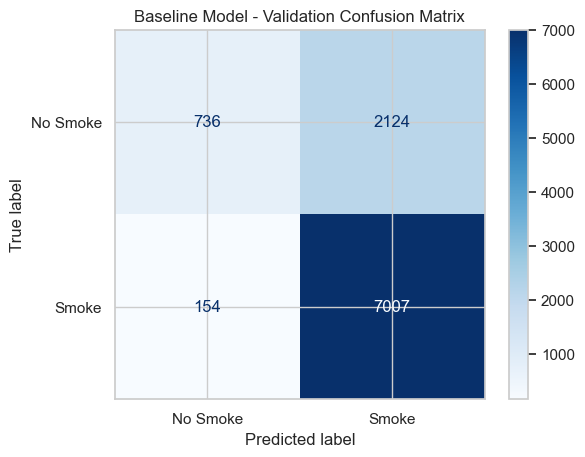

In [25]:
# Evaluate the baseline model on the validation set.
baseline_val_predictions = baseline_model.predict(X_val_scaled)

baseline_val_accuracy = accuracy_score(y_val, baseline_val_predictions)
baseline_val_precision = precision_score(y_val, baseline_val_predictions, zero_division=0)
baseline_val_recall = recall_score(y_val, baseline_val_predictions, zero_division=0)
baseline_val_f1 = f1_score(y_val, baseline_val_predictions, zero_division=0)

print(f'Validation accuracy:  {baseline_val_accuracy:.2%}')
print(f'Validation precision: {baseline_val_precision:.2%}')
print(f'Validation recall:    {baseline_val_recall:.2%}')
print(f'Validation F1-score:  {baseline_val_f1:.2%}')

print('\nValidation classification report:')
print(classification_report(y_val, baseline_val_predictions, target_names=['No Smoke', 'Smoke']))

baseline_val_confusion_matrix = confusion_matrix(y_val, baseline_val_predictions)
ConfusionMatrixDisplay(baseline_val_confusion_matrix, display_labels=['No Smoke', 'Smoke']).plot(cmap='Blues')
plt.title('Baseline Model - Validation Confusion Matrix')
plt.show()


#### 20. Train and Compare More Models on Validation Set

Now we train several models and compare them on the validation set.

The test set is still untouched. We only use validation results to choose the best model.


In [26]:
# Train multiple models and compare validation performance.

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Linear SVM': LinearSVC(max_iter=5000, random_state=42)
}

validation_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    val_predictions = model.predict(X_val_scaled)
    
    trained_models[model_name] = model
    validation_results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_val, val_predictions),
        'precision': precision_score(y_val, val_predictions, zero_division=0),
        'recall': recall_score(y_val, val_predictions, zero_division=0),
        'f1_score': f1_score(y_val, val_predictions, zero_division=0)
    })

validation_results = pd.DataFrame(validation_results)
validation_results = validation_results.sort_values(by='f1_score', ascending=False)

display(validation_results.style.format({
    'accuracy': '{:.2%}',
    'precision': '{:.2%}',
    'recall': '{:.2%}',
    'f1_score': '{:.2%}'
}))


,model,accuracy,precision,recall,f1_score
2,Random Forest,99.65%,99.68%,99.83%,99.76%
1,Decision Tree,99.59%,99.72%,99.71%,99.71%
3,KNN,99.23%,99.22%,99.71%,99.46%
0,Logistic Regression,77.27%,76.74%,97.85%,86.02%
4,Linear SVM,75.38%,75.19%,97.84%,85.03%


#### 21. Cross-Validate Random Forest

Cross-validation checks whether Random Forest performs consistently across several different training splits.

This gives a more stable view than one validation split alone.


Cross-validation F1-score: 0.9976 +/- 0.0003


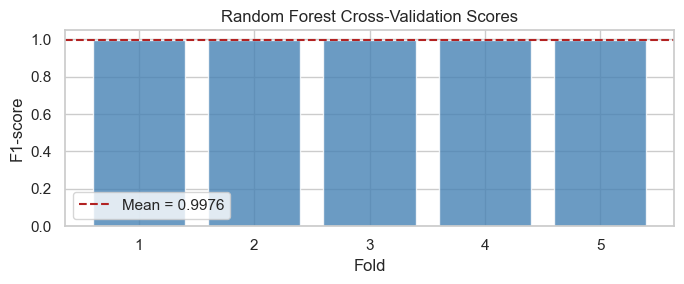

In [27]:
# Validate Random Forest with 5-fold stratified cross-validation on the training data.

random_forest_for_cv = RandomForestClassifier(n_estimators=100, random_state=42)

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    random_forest_for_cv,
    X_train_scaled,
    y_train,
    cv=folds,
    scoring='f1'
)

print(f'Cross-validation F1-score: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(cv_scores.mean(), color='firebrick', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1-score')
plt.title('Random Forest Cross-Validation Scores')
plt.legend()
plt.tight_layout()
plt.show()


#### 22. Random Forest Feature Importance

Feature importance shows which sensor columns Random Forest uses most when making predictions.

This helps explain the model, but it does not prove cause and effect.


,importance
tvoc_ppb,0.434063
humidity,0.293943
temperature,0.214496
eco2_ppm,0.057497


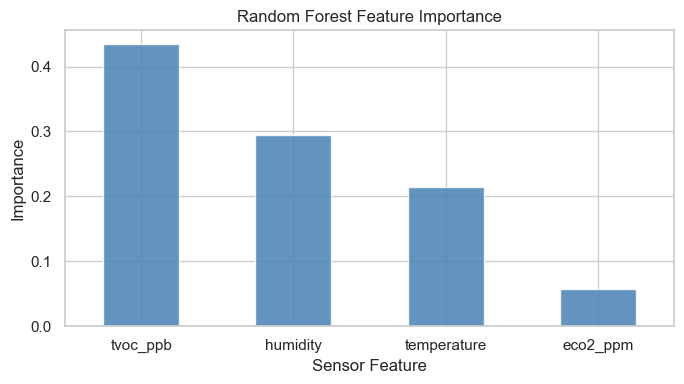

In [28]:
# Show which sensor features are most important for the Random Forest model.
random_forest_model = trained_models['Random Forest']

feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=features_col.columns
).sort_values(ascending=False)

display(feature_importance.rename('importance').to_frame())

plt.figure(figsize=(7, 4))
feature_importance.plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Sensor Feature')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### 23. Choose Best Model Based on Validation

The best model is selected using validation F1-score.

F1-score is useful here because it balances precision and recall.


In [29]:
# Choose the best model based on validation F1-score.
best_model_name = validation_results.iloc[0]['model']
best_validation_f1 = validation_results.iloc[0]['f1_score']

print('Best model based on validation:', best_model_name)
print(f'Best validation F1-score: {best_validation_f1:.2%}')


Best model based on validation: Random Forest
Best validation F1-score: 99.76%


#### 24. Final Test Evaluation

Now we evaluate the selected model on the test set.

This is the first time the test set is used, so it gives a fair final estimate of model performance.


Final model: Random Forest
Test accuracy:  99.70%
Test precision: 99.71%
Test recall:    99.87%
Test F1-score:  99.79%

Test classification report:
              precision    recall  f1-score   support

    No Smoke       1.00      0.99      0.99      3575
       Smoke       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



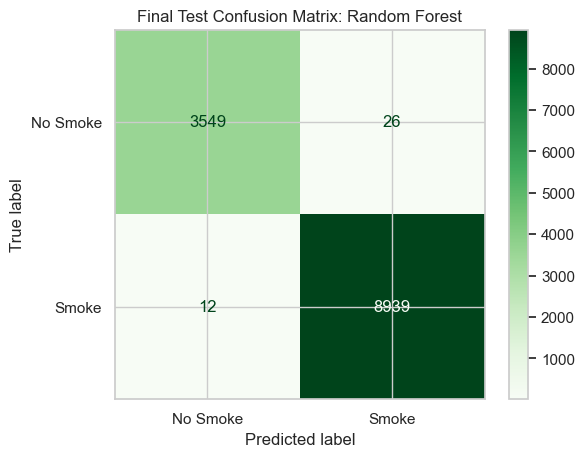

In [30]:
# Retrain the selected model on train + validation data, then test it once on the test set.

final_scaler = StandardScaler()
X_train_val_scaled = final_scaler.fit_transform(X_train_val)
X_test_final_scaled = final_scaler.transform(X_test)

X_train_val_scaled = pd.DataFrame(X_train_val_scaled, columns=features_col.columns, index=X_train_val.index)
X_test_final_scaled = pd.DataFrame(X_test_final_scaled, columns=features_col.columns, index=X_test.index)

final_model = clone(models[best_model_name])
final_model.fit(X_train_val_scaled, y_train_val)

final_test_predictions = final_model.predict(X_test_final_scaled)

final_accuracy = accuracy_score(y_test, final_test_predictions)
final_precision = precision_score(y_test, final_test_predictions, zero_division=0)
final_recall = recall_score(y_test, final_test_predictions, zero_division=0)
final_f1 = f1_score(y_test, final_test_predictions, zero_division=0)

print('Final model:', best_model_name)
print(f'Test accuracy:  {final_accuracy:.2%}')
print(f'Test precision: {final_precision:.2%}')
print(f'Test recall:    {final_recall:.2%}')
print(f'Test F1-score:  {final_f1:.2%}')

print('\nTest classification report:')
print(classification_report(y_test, final_test_predictions, target_names=['No Smoke', 'Smoke']))

final_confusion_matrix = confusion_matrix(y_test, final_test_predictions)
ConfusionMatrixDisplay(final_confusion_matrix, display_labels=['No Smoke', 'Smoke']).plot(cmap='Greens')
plt.title(f'Final Test Confusion Matrix: {best_model_name}')
plt.show()


#### 25. Final Conclusion

In this notebook, we completed the main ML workflow:

- Loaded the raw smoke detection dataset
- Kept and renamed the needed columns
- Added a readable `alarm_status` label
- Checked missing values, duplicates, distributions, outliers, and correlations
- Split the data into training, validation, and test sets
- Scaled the sensor features without data leakage
- Trained a baseline Logistic Regression model
- Compared multiple models using the validation set
- Cross-validated Random Forest
- Checked Random Forest feature importance
- Selected the best model using validation F1-score
- Evaluated the final model once on the test set

For smoke detection, recall is especially important because low recall means the model misses real smoke cases. F1-score is also useful because it balances missed smoke cases and false alarms.
